In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_places, available_cities
from src.recommender import TravelRecommender
from src.itinerary import generate_itinerary

print("✅ Environment ready")


d:\college_work\PG\linkedIn_projects\TravelMate-AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Environment ready


## 2. Load the dataset and shared recommender

In [2]:
df = load_places()

embedding_path = (
    PROJECT_ROOT
    / "data"
    / "embeddings"
    / "multi_city_place_embeddings.npy"
)

embeddings = None

if embedding_path.exists():
    candidate = np.load(embedding_path)

    if len(candidate) == len(df):
        embeddings = candidate
        print("✅ Loaded multi-city embeddings")
    else:
        print("⚠️ Embedding row count mismatch. Regenerating.")

recommender = TravelRecommender(
    df=df,
    place_embeddings=embeddings
)

print("Dataset:", df.shape)
print("Cities:", available_cities(df))


✅ Loaded multi-city embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5082.75it/s]


Dataset: (120, 27)
Cities: ['Goa', 'Jaipur', 'Manali', 'Rishikesh', 'Shimla', 'Udaipur']


## 3. Evaluation profile

In [3]:
PROFILE = {
    "nature": 1.0,
    "history": 0.2,
    "culture": 0.3,
    "adventure": 0.4,
    "photography": 1.0,
    "shopping": 0.1,
    "religious": 0.0,
    "family": 0.4,
}

QUERY = (
    "peaceful scenic places surrounded by nature "
    "with beautiful locations for photography"
)

print("✅ Evaluation profile ready")


✅ Evaluation profile ready


## 4. MMR-style diversification

We use a simplified Maximum Marginal Relevance idea:

```text
MMR = relevance - λ × redundancy
```

A candidate remains useful when it is relevant to the query but not too similar to places already selected.

This is a heuristic reranking method, not a newly trained ML model.


In [4]:
def mmr_diversify(
    result,
    recommender,
    top_n=5,
    lambda_relevance=0.70,
):
    if result.empty:
        return result.copy()

    pool = result.copy().reset_index(drop=True)

    # Map names to rows in the shared embedding matrix.
    positions = []

    for name in pool["name"].astype(str):
        matches = np.flatnonzero(
            recommender.df["name"].astype(str).eq(name).to_numpy()
        )

        positions.append(
            int(matches[0]) if len(matches) else None
        )

    selected = []
    selected_positions = []

    target = min(top_n, len(pool))

    while len(selected) < target:

        best_row = None
        best_score = -float("inf")

        for row_index in range(len(pool)):

            if row_index in selected:
                continue

            relevance = float(
                pool.loc[
                    row_index,
                    "final_score"
                ]
            )

            position = positions[row_index]

            if (
                position is None
                or not selected_positions
            ):
                redundancy = 0.0
            else:
                candidate_embedding = (
                    recommender.place_embeddings[position]
                )

                selected_embeddings = (
                    recommender.place_embeddings[
                        selected_positions
                    ]
                )

                similarity = (
                    selected_embeddings
                    @ candidate_embedding
                )

                redundancy = float(
                    np.max(similarity)
                )

            score = (
                lambda_relevance * relevance
                - (1.0 - lambda_relevance)
                * redundancy
            )

            if score > best_score:
                best_score = score
                best_row = row_index

        selected.append(best_row)

        if positions[best_row] is not None:
            selected_positions.append(
                positions[best_row]
            )

    output = (
        pool
        .iloc[selected]
        .copy()
        .reset_index(drop=True)
    )

    output["mmr_rank"] = range(
        1,
        len(output) + 1
    )

    return output


print("✅ MMR diversification ready")


✅ MMR diversification ready


## 5. Prepare itinerary metadata

In [5]:
def infer_activity_type(text):
    text = str(text).lower()

    if "waterfall" in text or "falls" in text:
        return "waterfall"
    if "rafting" in text:
        return "rafting"
    if "trek" in text:
        return "trekking"
    if "viewpoint" in text or "view point" in text:
        return "viewpoint"
    if any(
        x in text
        for x in ["temple", "church", "mosque", "gurudwara", "monastery"]
    ):
        return "religious_site"
    if any(
        x in text
        for x in ["fort", "palace", "museum", "heritage", "castle"]
    ):
        return "heritage"
    if any(
        x in text
        for x in ["market", "bazaar", "mall", "shopping"]
    ):
        return "shopping"
    if any(
        x in text
        for x in ["beach", "lake", "river", "park", "forest", "garden"]
    ):
        return "nature"
    if "snow" in text or "ski" in text:
        return "winter_experience"

    return "sightseeing"


def prepare_candidates(result):
    result = result.copy()

    text = (
        result["name"].fillna("").astype(str)
        + " "
        + result["category"].fillna("").astype(str)
    )

    result["activity_type"] = text.apply(
        infer_activity_type
    )

    duration_map = {
        "waterfall": 90,
        "rafting": 120,
        "trekking": 150,
        "viewpoint": 45,
        "religious_site": 60,
        "heritage": 120,
        "shopping": 90,
        "nature": 90,
        "winter_experience": 90,
        "sightseeing": 60,
    }

    result["estimated_visit_minutes"] = (
        result["activity_type"]
        .map(duration_map)
        .fillna(60)
        .astype(int)
    )

    result["estimated_price_level"] = 1

    return result


print("✅ Itinerary metadata helper ready")


✅ Itinerary metadata helper ready


## 6. Diversity helper

In [6]:
def diversity_score(result):
    if result.empty:
        return 0.0

    values = (
        result["activity_type"].astype(str)
        if "activity_type" in result.columns
        else result["category"].astype(str)
    )

    return values.nunique() / len(result)


## 7. Compare baseline and diversified recommendations

In [7]:
baseline = recommender.recommend(
    destination="Goa",
    query=QUERY,
    user_preferences=PROFILE,
    top_n=10,
)

baseline = prepare_candidates(baseline)

diversified = mmr_diversify(
    baseline,
    recommender,
    top_n=5,
    lambda_relevance=0.70,
)

print("BASELINE")
display(
    baseline[[
        "name",
        "activity_type",
        "final_score"
    ]].head(5)
)

print("\nDIVERSIFIED")
display(
    diversified[[
        "name",
        "activity_type",
        "final_score",
        "mmr_rank"
    ]]
)

print(
    "\nBaseline diversity:",
    round(
        diversity_score(
            baseline.head(5)
        ),
        4
    )
)

print(
    "Diversified diversity:",
    round(
        diversity_score(
            diversified
        ),
        4
    )
)


BASELINE


,name,activity_type,final_score
0,"Calangute Beach, Goa",nature,0.706152
1,Keri Beach,nature,0.672276
2,Kuske Waterfall,waterfall,0.640144
3,Twin Waterfall,waterfall,0.615357
4,Sinquerim Fort,heritage,0.578468



DIVERSIFIED


,name,activity_type,final_score,mmr_rank
0,"Calangute Beach, Goa",nature,0.706152,1
1,Kuske Waterfall,waterfall,0.640144,2
2,Keri Beach,nature,0.672276,3
3,Fort Aguada,heritage,0.569937,4
4,Dudhsagar Falls,waterfall,0.574811,5



Baseline diversity: 0.6
Diversified diversity: 0.6


## 8. Geographic-aware candidate ordering

In [8]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )


def geographic_reorder(
    candidates,
    average_speed_kmph=25,
):
    candidates = (
        candidates
        .copy()
        .reset_index(drop=True)
    )

    if candidates.empty:
        return candidates

    remaining = set(
        range(len(candidates))
    )

    ordered = []

    current = max(
        remaining,
        key=lambda idx: float(
            candidates.loc[
                idx,
                "final_score"
            ]
        )
    )

    ordered.append(current)
    remaining.remove(current)

    while remaining:

        best_idx = None
        best_value = -float("inf")

        for idx in remaining:

            distance_km = haversine_km(
                candidates.loc[
                    current,
                    "latitude"
                ],
                candidates.loc[
                    current,
                    "longitude"
                ],
                candidates.loc[
                    idx,
                    "latitude"
                ],
                candidates.loc[
                    idx,
                    "longitude"
                ],
            )

            travel_minutes = (
                distance_km
                / average_speed_kmph
                * 60
            )

            score = float(
                candidates.loc[
                    idx,
                    "final_score"
                ]
            )

            value = score / (
                1.0 + travel_minutes
            )

            if value > best_value:
                best_value = value
                best_idx = idx

        ordered.append(best_idx)
        remaining.remove(best_idx)
        current = best_idx

    return (
        candidates
        .iloc[ordered]
        .reset_index(drop=True)
    )


print("✅ Geographic ordering ready")


✅ Geographic ordering ready


## 9. Create an improved itinerary

In [9]:
def balanced_itinerary(
    candidates,
    days=3,
    max_day_minutes=7 * 60,
    average_speed_kmph=25,
):
    candidates = (
        candidates
        .copy()
        .reset_index(drop=True)
    )

    if candidates.empty:
        return pd.DataFrame()

    remaining = set(
        range(len(candidates))
    )

    # Each day maintains:
    # - selected rows
    # - used minutes
    # - last selected place
    day_rows = {
        day: []
        for day in range(1, days + 1)
    }

    day_minutes = {
        day: 0.0
        for day in range(1, days + 1)
    }

    last_index = {
        day: None
        for day in range(1, days + 1)
    }

    while remaining:

        progress = False

        # Fill the lightest day first.
        day_order = sorted(
            range(1, days + 1),
            key=lambda day: (
                day_minutes[day],
                len(day_rows[day]),
                day,
            )
        )

        for day in day_order:

            if not remaining:
                break

            current = last_index[day]
            feasible = []

            for idx in remaining:

                if current is None:
                    travel = 0.0
                else:
                    distance_km = haversine_km(
                        candidates.loc[
                            current,
                            "latitude"
                        ],
                        candidates.loc[
                            current,
                            "longitude"
                        ],
                        candidates.loc[
                            idx,
                            "latitude"
                        ],
                        candidates.loc[
                            idx,
                            "longitude"
                        ],
                    )

                    travel = (
                        distance_km
                        / average_speed_kmph
                        * 60
                    )

                visit = float(
                    candidates.loc[
                        idx,
                        "estimated_visit_minutes"
                    ]
                )

                total = (
                    day_minutes[day]
                    + travel
                    + visit
                )

                if total <= max_day_minutes + 1e-9:

                    relevance = float(
                        candidates.loc[
                            idx,
                            "final_score"
                        ]
                    )

                    value = (
                        relevance
                        / (1.0 + travel)
                    )

                    feasible.append(
                        (
                            idx,
                            travel,
                            visit,
                            value,
                        )
                    )

            if not feasible:
                continue

            idx, travel, visit, _ = max(
                feasible,
                key=lambda x: x[3]
            )

            arrival = (
                9 * 60
                + day_minutes[day]
                + travel
            )

            departure = (
                arrival + visit
            )

            hour_a = int(arrival // 60)
            minute_a = int(round(arrival % 60))

            hour_d = int(departure // 60)
            minute_d = int(round(departure % 60))

            def display_time(hour, minute):
                suffix = "AM" if hour < 12 else "PM"
                h = hour % 12 or 12
                return f"{h}:{minute:02d} {suffix}"

            day_rows[day].append({
                "city": candidates.loc[
                    idx,
                    "city"
                ],
                "day": day,
                "stop": len(
                    day_rows[day]
                ) + 1,
                "place": candidates.loc[
                    idx,
                    "name"
                ],
                "activity_type": candidates.loc[
                    idx,
                    "activity_type"
                ],
                "arrival": display_time(
                    hour_a,
                    minute_a
                ),
                "departure": display_time(
                    hour_d,
                    minute_d
                ),
                "travel_before_minutes":
                    round(travel, 2),
                "visit_minutes":
                    int(round(visit)),
                "estimated_price_level":
                    int(
                        candidates.loc[
                            idx,
                            "estimated_price_level"
                        ]
                    ),
                "final_score":
                    round(
                        float(
                            candidates.loc[
                                idx,
                                "final_score"
                            ]
                        ),
                        4
                    ),
                "latitude":
                    float(
                        candidates.loc[
                            idx,
                            "latitude"
                        ]
                    ),
                "longitude":
                    float(
                        candidates.loc[
                            idx,
                            "longitude"
                        ]
                    ),
            })

            day_minutes[day] += (
                travel + visit
            )

            last_index[day] = idx
            remaining.remove(idx)
            progress = True

        if not progress:
            break

    rows = []

    for day in range(1, days + 1):
        rows.extend(day_rows[day])

    return pd.DataFrame(rows)


## 10. Compare baseline vs improved itinerary

In [10]:
baseline_candidates = prepare_candidates(
    recommender.recommend(
        destination="Goa",
        query=QUERY,
        user_preferences=PROFILE,
        top_n=12,
    )
)

improved_candidates = mmr_diversify(
    baseline_candidates,
    recommender,
    top_n=12,
    lambda_relevance=0.70,
)

improved_candidates = (
    improved_candidates
    .reset_index(drop=True)
)

baseline_plan = generate_itinerary(
    baseline_candidates,
    days=3,
    max_day_minutes=7 * 60,
    average_speed_kmph=25,
)

improved_plan = balanced_itinerary(
    improved_candidates,
    days=3,
    max_day_minutes=7 * 60,
    average_speed_kmph=25,
)

print("Baseline:")
display(baseline_plan)

print("Improved:")
display(improved_plan)


Baseline:


,city,day,stop,place,activity_type,arrival,departure,travel_before_minutes,visit_minutes,estimated_price_level,final_score,latitude,longitude
0,Goa,1,1,"Calangute Beach, Goa",nature,9:00 AM,10:30 AM,0.00,90,1,0.7062,15.544721,73.754669
1,Goa,1,2,Sinquerim Fort,heritage,10:43 AM,12:43 PM,12.71,120,1,0.5785,15.498466,73.766404
2,Goa,1,3,Fort Aguada,heritage,12:45 PM,2:45 PM,2.51,120,1,0.5699,15.492252,73.773746
3,Goa,2,1,Keri Beach,nature,9:00 AM,10:30 AM,0.00,90,1,0.6723,15.708774,73.692984
4,Goa,2,2,Chapora Fort,heritage,11:00 AM,1:00 PM,30.00,120,1,0.5399,15.604638,73.736963
5,Goa,2,3,Kesarval Spring Verna Waterfall,waterfall,2:17 PM,3:47 PM,77.16,90,1,0.5677,15.382312,73.928801
6,Goa,3,1,Kuske Waterfall,waterfall,9:00 AM,10:30 AM,0.00,90,1,0.6401,15.021708,74.208660
7,Goa,3,2,Cabo de Rama Fort South Goa,heritage,11:46 AM,1:46 PM,76.11,120,1,0.5772,15.088785,73.921593
8,Goa,3,3,Sunset View Point Colva,viewpoint,2:36 PM,3:21 PM,49.70,45,1,0.5587,15.274854,73.913585


Improved:


,city,day,stop,place,activity_type,arrival,departure,travel_before_minutes,visit_minutes,estimated_price_level,final_score,latitude,longitude
0,Goa,1,1,"Calangute Beach, Goa",nature,9:00 AM,10:30 AM,0.00,90,1,0.7062,15.544721,73.754669
1,Goa,1,2,Sinquerim Fort,heritage,10:43 AM,12:43 PM,12.71,120,1,0.5785,15.498466,73.766404
2,Goa,1,3,Fort Aguada,heritage,12:45 PM,2:45 PM,2.51,120,1,0.5699,15.492252,73.773746
3,Goa,2,1,Keri Beach,nature,9:00 AM,10:30 AM,0.00,90,1,0.6723,15.708774,73.692984
4,Goa,2,2,Chapora Fort,heritage,11:00 AM,1:00 PM,30.00,120,1,0.5399,15.604638,73.736963
5,Goa,2,3,Kesarval Spring Verna Waterfall,waterfall,2:17 PM,3:47 PM,77.16,90,1,0.5677,15.382312,73.928801
6,Goa,3,1,Kuske Waterfall,waterfall,9:00 AM,10:30 AM,0.00,90,1,0.6401,15.021708,74.208660
7,Goa,3,2,Cabo de Rama Fort South Goa,heritage,11:46 AM,1:46 PM,76.11,120,1,0.5772,15.088785,73.921593
8,Goa,3,3,Sunset View Point Colva,viewpoint,2:36 PM,3:21 PM,49.70,45,1,0.5587,15.274854,73.913585


## 11. Compare itinerary statistics

In [11]:
def itinerary_summary(plan):
    if plan.empty:
        return {
            "stops": 0,
            "days_used": 0,
            "travel_minutes": 0.0,
            "average_daily_minutes": 0.0,
            "max_daily_minutes": 0.0,
        }

    daily = (
        plan
        .assign(
            total_minutes=lambda x:
                x["travel_before_minutes"]
                + x["visit_minutes"]
        )
        .groupby("day")["total_minutes"]
        .sum()
    )

    return {
        "stops": len(plan),
        "days_used": int(
            plan["day"].nunique()
        ),
        "travel_minutes": float(
            plan["travel_before_minutes"].sum()
        ),
        "average_daily_minutes": float(
            daily.mean()
        ),
        "max_daily_minutes": float(
            daily.max()
        ),
    }


comparison = pd.DataFrame([
    {
        "version": "Baseline",
        **itinerary_summary(
            baseline_plan
        )
    },
    {
        "version": "Improved",
        **itinerary_summary(
            improved_plan
        )
    },
])

comparison


,version,stops,days_used,travel_minutes,average_daily_minutes,max_daily_minutes
0,Baseline,9,3,248.19,377.73,407.16
1,Improved,9,3,248.19,377.73,407.16


## 12. Evaluate the improvement across all cities

In [12]:
multi_city_comparison = []

for city in available_cities(df):

    base = prepare_candidates(
        recommender.recommend(
            destination=city,
            query=QUERY,
            user_preferences=PROFILE,
            top_n=12,
        )
    )

    diversified = mmr_diversify(
        base,
        recommender,
        top_n=12,
        lambda_relevance=0.70,
    )

    base_plan = generate_itinerary(
        base,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    improved_plan_city = balanced_itinerary(
        diversified,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    base_summary = itinerary_summary(
        base_plan
    )

    improved_summary = itinerary_summary(
        improved_plan_city
    )

    multi_city_comparison.append({
        "city": city,
        "baseline_stops":
            base_summary["stops"],
        "improved_stops":
            improved_summary["stops"],
        "baseline_days_used":
            base_summary["days_used"],
        "improved_days_used":
            improved_summary["days_used"],
        "baseline_travel_minutes":
            base_summary["travel_minutes"],
        "improved_travel_minutes":
            improved_summary["travel_minutes"],
        "baseline_max_daily_minutes":
            base_summary["max_daily_minutes"],
        "improved_max_daily_minutes":
            improved_summary["max_daily_minutes"],
    })

multi_city_comparison_df = pd.DataFrame(
    multi_city_comparison
)

multi_city_comparison_df


,city,baseline_stops,improved_stops,baseline_days_used,improved_days_used,baseline_travel_minutes,improved_travel_minutes,baseline_max_daily_minutes,improved_max_daily_minutes
0,Goa,9,9,3,3,248.19,248.19,407.16,407.16
1,Jaipur,11,10,3,3,19.67,38.33,400.83,377.87
2,Manali,12,12,3,3,42.63,55.05,394.48,379.70
3,Rishikesh,12,12,3,3,39.24,61.71,379.51,385.39
4,Shimla,12,12,3,3,24.77,29.17,410.84,337.50
5,Udaipur,12,12,3,3,28.89,28.47,396.23,399.72


## 13. Validate every improved itinerary

In [13]:
valid_rows = []

for city in available_cities(df):

    recommendations = recommender.recommend(
        destination=city,
        query=QUERY,
        user_preferences=PROFILE,
        top_n=12,
    )

    recommendations = prepare_candidates(
        recommendations
    )

    recommendations = mmr_diversify(
        recommendations,
        recommender,
        top_n=12,
        lambda_relevance=0.70,
    )

    plan = balanced_itinerary(
        recommendations,
        days=3,
        max_day_minutes=7 * 60,
        average_speed_kmph=25,
    )

    if plan.empty:
        budget_valid = True
        city_valid = False
    else:
        daily = (
            plan
            .assign(
                total_minutes=lambda x:
                    x["travel_before_minutes"]
                    + x["visit_minutes"]
            )
            .groupby(
                ["city", "day"]
            )["total_minutes"]
            .sum()
        )

        budget_valid = bool(
            (
                daily
                <= 7 * 60 + 1e-9
            ).all()
        )

        city_valid = bool(
            plan["city"].eq(city).all()
        )

    valid_rows.append({
        "city": city,
        "budget_valid": budget_valid,
        "city_valid": city_valid,
    })

validation_df = pd.DataFrame(
    valid_rows
)

validation_df


,city,budget_valid,city_valid
0,Goa,True,True
1,Jaipur,True,True
2,Manali,True,True
3,Rishikesh,True,True
4,Shimla,True,True
5,Udaipur,True,True


## 14. Hard validation

In [14]:
assert validation_df[
    "budget_valid"
].all()

assert validation_df[
    "city_valid"
].all()

print(
    "✅ All improved itineraries satisfy "
    "city and time constraints."
)


✅ All improved itineraries satisfy city and time constraints.


## 15. Visualize baseline vs improved travel time

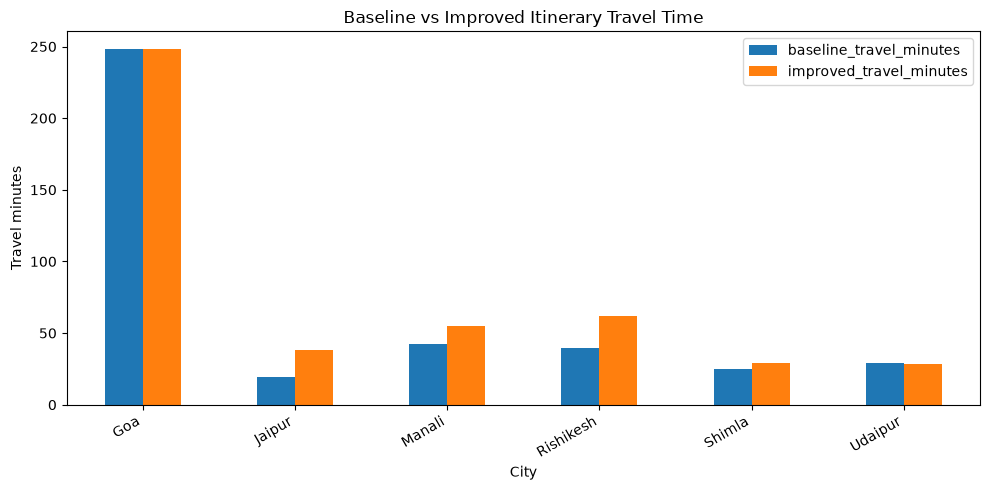

In [15]:
plot_df = (
    multi_city_comparison_df
    .set_index("city")
)

plot_df[
    [
        "baseline_travel_minutes",
        "improved_travel_minutes",
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Baseline vs Improved Itinerary Travel Time"
)

plt.ylabel("Travel minutes")

plt.xlabel("City")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


## 16. Visualize days used

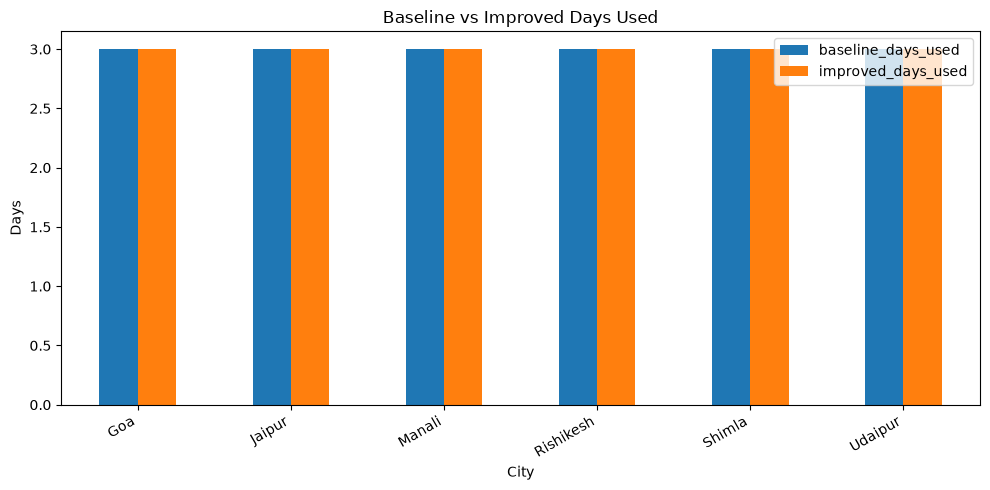

In [16]:
plot_df[
    [
        "baseline_days_used",
        "improved_days_used",
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Baseline vs Improved Days Used"
)

plt.ylabel("Days")

plt.xlabel("City")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


## 17. Save improvement results

In [17]:
evaluation_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "evaluation"
)

evaluation_dir.mkdir(
    parents=True,
    exist_ok=True
)

multi_city_comparison_df.to_csv(
    evaluation_dir
    / "recommendation_itinerary_improvement.csv",
    index=False
)

validation_df.to_csv(
    evaluation_dir
    / "improved_itinerary_validation.csv",
    index=False
)

comparison.to_csv(
    evaluation_dir
    / "goa_baseline_vs_improved.csv",
    index=False
)

print(
    f"✅ Saved results to {evaluation_dir}"
)


✅ Saved results to D:\college_work\PG\linkedIn_projects\TravelMate-AI\data\processed\evaluation


# 🏁 Improvement milestone

We now have experimentally compared:

```text
Baseline recommender
        ↓
Diversified recommender

Baseline itinerary
        ↓
Balanced/geographic-aware itinerary
```

The important rule is:

```text
Do not call the improved method better
until the evaluation shows an improvement.
```

### Next step

Use these results to decide which changes should be promoted into `src/`.

Only then should FastAPI and Streamlit be updated to use the improved engine.
